<a href="https://colab.research.google.com/github/dt662/DL_project/blob/main/DL_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Load file

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd '/content/drive/MyDrive/Colab save'


/content/drive/MyDrive/Colab save


## Chuẩn bị dữ liệu (Cập nhật đường dẫn)



In [3]:
import torchvision

train_data_dir = '/content/drive/MyDrive/Colab save/dataset_split/train'
val_data_dir = '/content/drive/MyDrive/Colab save/dataset_split/val'

print("Defined data directories for training and validation.")

Defined data directories for training and validation.


In [4]:
from torchvision.datasets import ImageFolder
import os

# Tải dữ liệu huấn luyện và xác thực
# Check if the directories exist before trying to load data
if os.path.exists(train_data_dir) and os.path.exists(val_data_dir):
    train_dataset = ImageFolder(root=train_data_dir)
    val_dataset = ImageFolder(root=val_data_dir)

    # Lấy số lượng lớp từ train_dataset
    num_classes = len(train_dataset.classes)

    print(f"Tải thành công dữ liệu huấn luyện từ: {train_data_dir}")
    print(f"Tải thành công dữ liệu xác thực từ: {val_data_dir}")
    print(f"Số lượng lớp được nhận diện: {num_classes}")
else:
    if not os.path.exists(train_data_dir):
        print(f"Lỗi: Thư mục huấn luyện không tồn tại: {train_data_dir}. Vui lòng kiểm tra lại đường dẫn hoặc cấu trúc dữ liệu trên Google Drive của bạn.")
    if not os.path.exists(val_data_dir):
        print(f"Lỗi: Thư mục xác thực không tồn tại: {val_data_dir}. Vui lòng kiểm tra lại đường dẫn hoặc cấu trúc dữ liệu trên Google Drive của bạn.")
    print("Không thể tải dữ liệu do thiếu một hoặc nhiều thư mục.")

Tải thành công dữ liệu huấn luyện từ: /content/drive/MyDrive/Colab save/dataset_split/train
Tải thành công dữ liệu xác thực từ: /content/drive/MyDrive/Colab save/dataset_split/val
Số lượng lớp được nhận diện: 29


## Cập nhật kiến trúc mạng


In [5]:
import torch
import torch.nn as nn
import torchvision.models

# 2. Tải mô hình MobileNetV2 đã được huấn luyện trước
model = torchvision.models.mobilenet_v2(pretrained=True)

# 3. Đóng băng các tham số của tất cả các lớp trong mô hình đã tải
for param in model.parameters():
    param.requires_grad = False

# 4. Truy cập vào lớp phân loại cuối cùng của MobileNetV2
# 5. Xác định số lượng đặc trưng đầu vào cho lớp cuối cùng
in_features = model.classifier[1].in_features

# 6. Thay thế lớp phân loại cuối cùng bằng một lớp nn.Linear mới
model.classifier[1] = nn.Linear(in_features, num_classes)

# 7. In cấu trúc mô hình đã sửa đổi để xác nhận sự thay đổi của lớp cuối cùng
print("Cấu trúc mô hình MobileNetV2 đã được sửa đổi:")
print(model.classifier)
print(f"Số lượng đặc trưng đầu vào cho lớp cuối cùng: {in_features}")
print(f"Số lượng lớp đầu ra mới: {num_classes}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 145MB/s]

Cấu trúc mô hình MobileNetV2 đã được sửa đổi:
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=29, bias=True)
)
Số lượng đặc trưng đầu vào cho lớp cuối cùng: 1280
Số lượng lớp đầu ra mới: 29


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Mô hình đã được chuyển đến: {device}")

Mô hình đã được chuyển đến: cpu


## Thay đổi hàm mất mát



In [7]:
import torch.optim

# 2. Khởi tạo hàm mất mát (criterion) là nn.CrossEntropyLoss()
criterion = nn.CrossEntropyLoss()

# 3. Khởi tạo bộ tối ưu hóa (optimizer) sử dụng torch.optim.Adam
# Lấy các tham số có thể huấn luyện của mô hình
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 4. In ra hàm mất mát và bộ tối ưu hóa đã được khởi tạo để xác nhận
print(f"Hàm mất mát đã khởi tạo: {criterion}")
print(f"Bộ tối ưu hóa đã khởi tạo: {optimizer}")

Hàm mất mát đã khởi tạo: CrossEntropyLoss()
Bộ tối ưu hóa đã khởi tạo: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## Điều chỉnh hàm huấn luyện


In [8]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()  # Đặt mô hình ở chế độ huấn luyện
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for inputs, labels in dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Đảm bảo nhãn có kiểu dữ liệu là long() cho CrossEntropyLoss
        labels = labels.long()

        # Đặt gradient của bộ tối ưu hóa về 0
        optimizer.zero_grad()

        # Thực hiện phép truyền thuận (forward pass)
        outputs = model(inputs)

        # Tính toán hàm mất mát
        loss = criterion(outputs, labels)

        # Thực hiện phép truyền ngược (backward pass)
        loss.backward()

        # Cập nhật trọng số của mô hình
        optimizer.step()

        # Theo dõi tổng giá trị mất mát
        running_loss += loss.item() * inputs.size(0)

        # Theo dõi số lượng dự đoán đúng
        _, predicted = torch.max(outputs.data, 1)
        correct_predictions += (predicted == labels).sum().item()
        total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples

    return epoch_loss, epoch_accuracy

print("Hàm train_one_epoch đã được định nghĩa.")

Hàm train_one_epoch đã được định nghĩa.


## Điều chỉnh hàm đánh giá


In [9]:
def evaluate(model, dataloader, criterion, device):
    model.eval()  # Đặt mô hình ở chế độ đánh giá
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():  # Vô hiệu hóa tính toán gradient
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Đảm bảo nhãn có kiểu dữ liệu là long() cho CrossEntropyLoss
            labels = labels.long()

            # Thực hiện phép truyền thuận (forward pass)
            outputs = model(inputs)

            # Tính toán hàm mất mát
            loss = criterion(outputs, labels)

            # Theo dõi tổng giá trị mất mát
            running_loss += loss.item() * inputs.size(0)

            # Lấy lớp dự đoán có xác suất cao nhất
            _, predicted = torch.max(outputs.data, 1)

            # Theo dõi số lượng dự đoán đúng
            correct_predictions += (predicted == labels).sum().item()
            total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples

    return epoch_loss, epoch_accuracy

print("Hàm evaluate đã được định nghĩa.")

Hàm evaluate đã được định nghĩa.


## Xử lý ảnh

In [10]:
from torchvision import transforms
import cv2
import numpy as np
from PIL import Image, ImageFilter
import os
import sys

# Custom Transform for Face Cropping
class FaceCropTransform:
    def __init__(self, cascade_filename='haarcascade_frontalface_default.xml', padding=0.2):

        python_version_path = f'/usr/local/lib/python{sys.version_info.major}.{sys.version_info.minor}/dist-packages'
        common_cascade_paths = [
            os.path.join(python_version_path, f'cv2/data/{cascade_filename}'),
            f'/opt/conda/share/opencv4/haarcascades/{cascade_filename}',
            f'/usr/share/opencv4/haarcascades/{cascade_filename}'
        ]
        cascade_path = None
        for path in common_cascade_paths:
            if os.path.exists(path):
                cascade_path = path
                break

        if cascade_path:
            self.face_cascade = cv2.CascadeClassifier(cascade_path)
            if self.face_cascade.empty():
                print(f"WARNING: Face cascade found at {cascade_path}, but failed to load. Face cropping will default to center crop.")
                self.face_cascade = None
            else:
                print(f"Face cascade loaded from: {cascade_path}")
        else:
            print(f"WARNING: Face cascade file '{cascade_filename}' not found in common paths. Face cropping will default to center crop.")
            self.face_cascade = None

        self.padding = padding

    def __call__(self, img):
        if self.face_cascade is None:

            width, height = img.size
            target_dim = min(width, height)
            left = (width - target_dim) / 2
            top = (height - target_dim) / 2
            right = (width + target_dim) / 2
            bottom = (height + target_dim) / 2
            return img.crop((left, top, right, bottom))



        img_np = np.array(img.convert('RGB'))
        img_cv = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
        gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)

        faces = self.face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(30, 30),
            flags=cv2.CASCADE_SCALE_IMAGE
        )

        if len(faces) > 0:
            # Take the largest face
            (x, y, w, h) = max(faces, key=lambda rect: rect[2] * rect[3])

            # Apply padding
            x_pad = int(w * self.padding)
            y_pad = int(h * self.padding)
            x_start = max(0, x - x_pad)
            y_start = max(0, y - y_pad)
            x_end = min(img_np.shape[1], x + w + x_pad)
            y_end = min(img_np.shape[0], y + h + y_pad)

            cropped_face_np = img_np[y_start:y_end, x_start:x_end]
            return Image.fromarray(cropped_face_np)
        else:
            width, height = img.size
            target_dim = min(width, height)
            left = (width - target_dim) / 2
            top = (height - target_dim) / 2
            right = (width + target_dim) / 2
            bottom = (height + target_dim) / 2
            return img.crop((left, top, right, bottom))

train_transform = transforms.Compose([
    FaceCropTransform(),
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.5), # Added noise filtering (Gaussian blur)
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    FaceCropTransform(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])


Face cascade loaded from: /usr/local/lib/python3.12/dist-packages/cv2/data/haarcascade_frontalface_default.xml
Face cascade loaded from: /usr/local/lib/python3.12/dist-packages/cv2/data/haarcascade_frontalface_default.xml


## Huấn luyện mô hình




In [11]:
from torch.utils.data import DataLoader

# Khởi tạo lại dataset với transform đã định nghĩa
# Nếu train_dataset và val_dataset chưa được gán transform, chúng ta cần gán nó ở đây.
# Giả sử `transform` đã được định nghĩa ở bước trước và muốn áp dụng cho cả train và val.
train_dataset = ImageFolder(root=train_data_dir, transform=train_transform)
val_dataset = ImageFolder(root=val_data_dir, transform=val_transform)

# 1. Khởi tạo DataLoader cho tập dữ liệu huấn luyện và xác thực
batch_size = 16

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Đã khởi tạo train_dataloader với {len(train_dataloader)} batches.")
print(f"Đã khởi tạo val_dataloader với {len(val_dataloader)} batches.")


Đã khởi tạo train_dataloader với 26 batches.
Đã khởi tạo val_dataloader với 11 batches.


Epoch 1/50
  [Train] Loss: 3.3903, Accuracy: 0.0672
  [Validation] Loss: 2.8370, Accuracy: 0.2254
Epoch 2/50
  [Train] Loss: 2.5736, Accuracy: 0.3557
  [Validation] Loss: 2.3108, Accuracy: 0.4104
Epoch 3/50
  [Train] Loss: 2.0638, Accuracy: 0.5025
  [Validation] Loss: 1.9049, Accuracy: 0.5607
Epoch 4/50
  [Train] Loss: 1.6509, Accuracy: 0.6692
  [Validation] Loss: 1.6672, Accuracy: 0.5954
Epoch 5/50
  [Train] Loss: 1.3958, Accuracy: 0.7388
  [Validation] Loss: 1.5235, Accuracy: 0.6532
Epoch 6/50
  [Train] Loss: 1.0977, Accuracy: 0.8060
  [Validation] Loss: 1.4143, Accuracy: 0.7052
Epoch 7/50
  [Train] Loss: 1.0071, Accuracy: 0.8308
  [Validation] Loss: 1.2277, Accuracy: 0.7457
Epoch 8/50
  [Train] Loss: 0.8884, Accuracy: 0.8557
  [Validation] Loss: 1.1869, Accuracy: 0.7341
Epoch 9/50
  [Train] Loss: 0.7985, Accuracy: 0.8582
  [Validation] Loss: 1.1473, Accuracy: 0.7283
Epoch 10/50
  [Train] Loss: 0.7035, Accuracy: 0.9005
  [Validation] Loss: 1.0736, Accuracy: 0.7514
Epoch 11/50
  [Trai

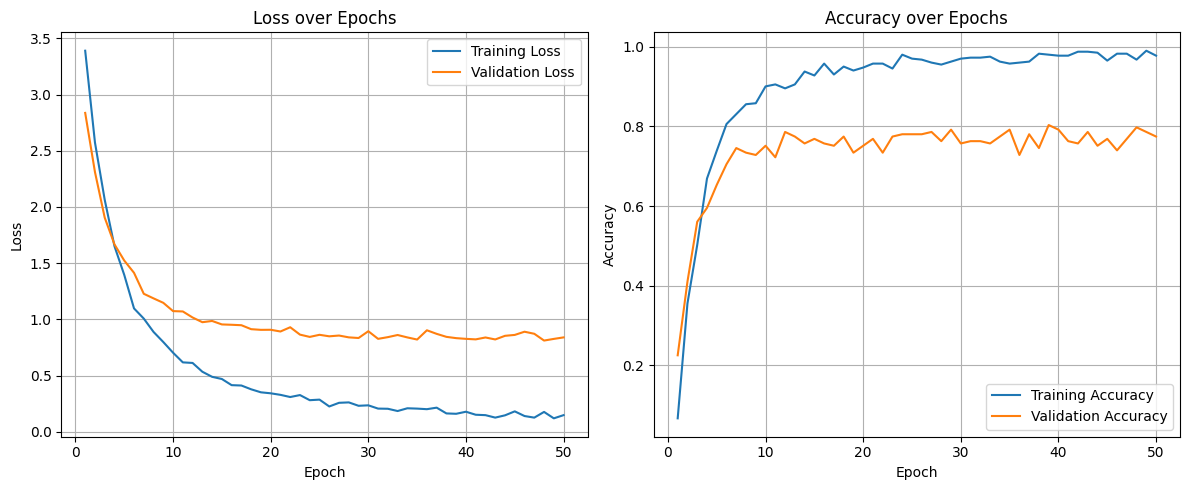

In [12]:
import matplotlib.pyplot as plt
import torch

num_epochs = 50

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")

    # Huấn luyện mô hình
    train_loss, train_accuracy = train_one_epoch(model, train_dataloader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    print(f"  [Train] Loss: {train_loss:.4f}, Accuracy: {train_accuracy:.4f}")

    # Đánh giá mô hình
    val_loss, val_accuracy = evaluate(model, val_dataloader, criterion, device)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    print(f"  [Validation] Loss: {val_loss:.4f}, Accuracy: {val_accuracy:.4f}")

print("Quá trình huấn luyện và đánh giá đã hoàn tất.")

# Vẽ biểu đồ Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Vẽ biểu đồ Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accuracies, label='Training Accuracy')
plt.plot(range(1, num_epochs + 1), val_accuracies, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Kiểm tra với một số ảnh mới

In [13]:
import torch.nn.functional as F
from PIL import Image

class_names = train_dataset.classes

def predict_image(image: Image.Image, model, device, class_names, transform):
    model.eval()  # Đặt mô hình ở chế độ đánh giá

    with torch.no_grad():  # Vô hiệu hóa tính toán gradient
        # Áp dụng các biến đổi cho ảnh đầu vào và thêm một chiều batch
        input_tensor = transform(image).unsqueeze(0)
        input_tensor = input_tensor.to(device)

        # Đưa ảnh qua mô hình
        outputs = model(input_tensor)

        # Áp dụng softmax để chuyển đổi logits thành xác suất
        probabilities = F.softmax(outputs, dim=1)

        # Lấy chỉ mục của lớp có xác suất cao nhất
        predicted_idx = torch.argmax(probabilities, dim=1).item()

        # Lấy tên lớp dự đoán
        predicted_class = class_names[predicted_idx]

        # Trả về tên lớp dự đoán và xác suất của tất cả các lớp
        return predicted_class, probabilities.squeeze().cpu().numpy()

print("Hàm predict_image đã được định nghĩa.")

Hàm predict_image đã được định nghĩa.


Kiểm tra mô hình trên các ảnh trong thư mục: Test/New

--- Ảnh: Test/New/BKtest2.jpg ---


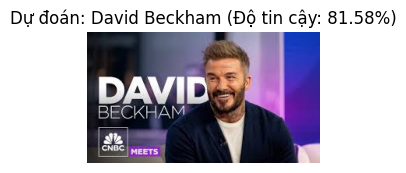


--- Ảnh: Test/New/Charles_leclerc.png ---


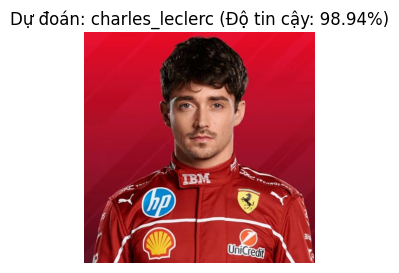


--- Ảnh: Test/New/tom cruise.jpg ---


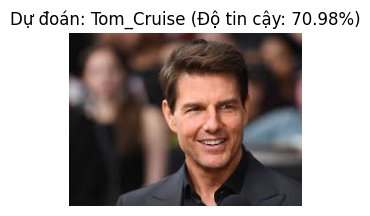


--- Ảnh: Test/New/messi.jpg ---


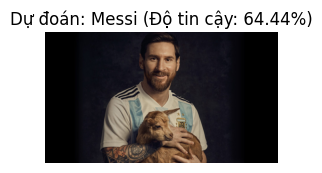


--- Ảnh: Test/New/taylor swift.webp ---


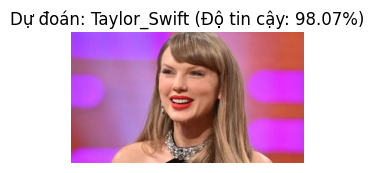


--- Ảnh: Test/New/j97.jpg ---


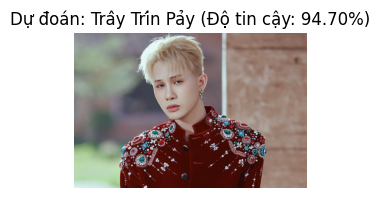

In [15]:
from PIL import Image
import numpy as np
import os
import matplotlib.pyplot as plt

# Đường dẫn đến thư mục chứa các tệp ảnh bạn muốn kiểm tra
# Thay thế bằng đường dẫn đến thư mục của bạn trên Google Drive
test_image_directory = 'Test/New' # Giả sử 'Test' là thư mục chứa nhiều ảnh

# Danh sách các đuôi file ảnh hợp lệ
IMAGE_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff', '.webp')

if not os.path.isdir(test_image_directory):
    print(f"Lỗi: Thư mục ảnh không tồn tại tại đường dẫn: {test_image_directory}")
    print("Vui lòng kiểm tra lại đường dẫn và đảm bảo thư mục ảnh tồn tại.")
else:
    print(f"Kiểm tra mô hình trên các ảnh trong thư mục: {test_image_directory}")

    # Lặp qua tất cả các tệp trong thư mục
    for filename in os.listdir(test_image_directory):
        if filename.lower().endswith(IMAGE_EXTENSIONS):
            test_image_path = os.path.join(test_image_directory, filename)
            try:
                # Mở ảnh
                test_image = Image.open(test_image_path).convert('RGB')

                # Dự đoán
                predicted_class, probabilities = predict_image(test_image, model, device, class_names, val_transform)

                print(f"\n--- Ảnh: {test_image_path} ---")

                # Tìm xác suất cao nhất
                max_prob = np.max(probabilities)*100

                # Hiển thị ảnh và kết quả dự đoán
                plt.figure(figsize=(3, 3))
                plt.imshow(test_image)
                plt.title(f"Dự đoán: {predicted_class} (Độ tin cậy: {max_prob:.2f}%)")
                plt.axis('off')
                plt.show()

            except Exception as e:
                print(f"Đã xảy ra lỗi khi xử lý ảnh {test_image_path}: {e}")
        else:
            print(f"Bỏ qua tệp không phải ảnh: {filename}")